In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks


file_path = "../../data/raw/WESAD/S2/S2_respiban.txt"

respiban = pd.read_csv(
    file_path,
    sep="\t",        # change to " " if space-separated
    header=None,
    comment="#",     # ignores metadata lines starting with #
)

print(respiban.head())
print(respiban.shape)

   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN
(4442067, 11)


[31364 31379 31367 31076 31365 31361 31365 31367 31380 31357]


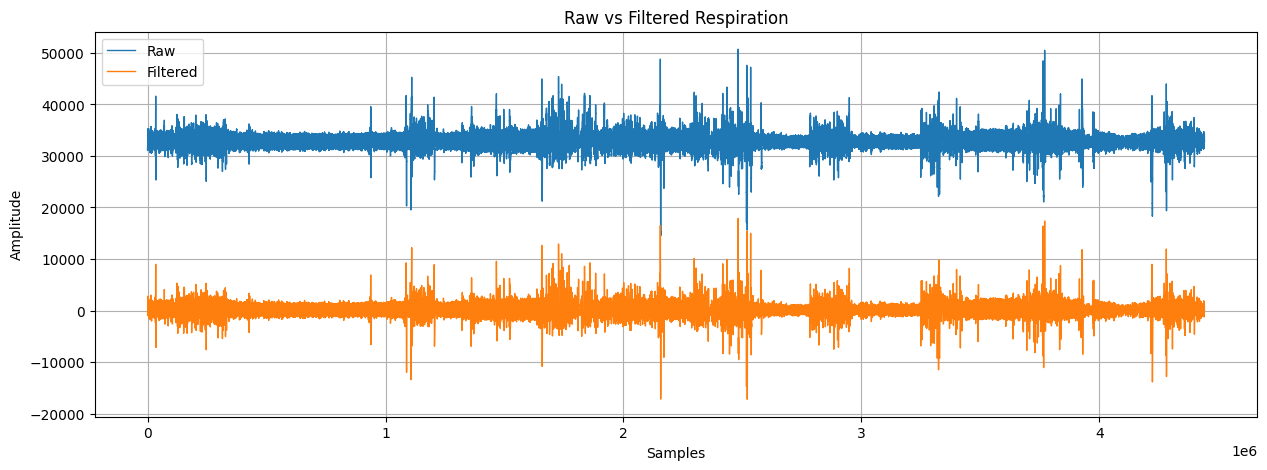

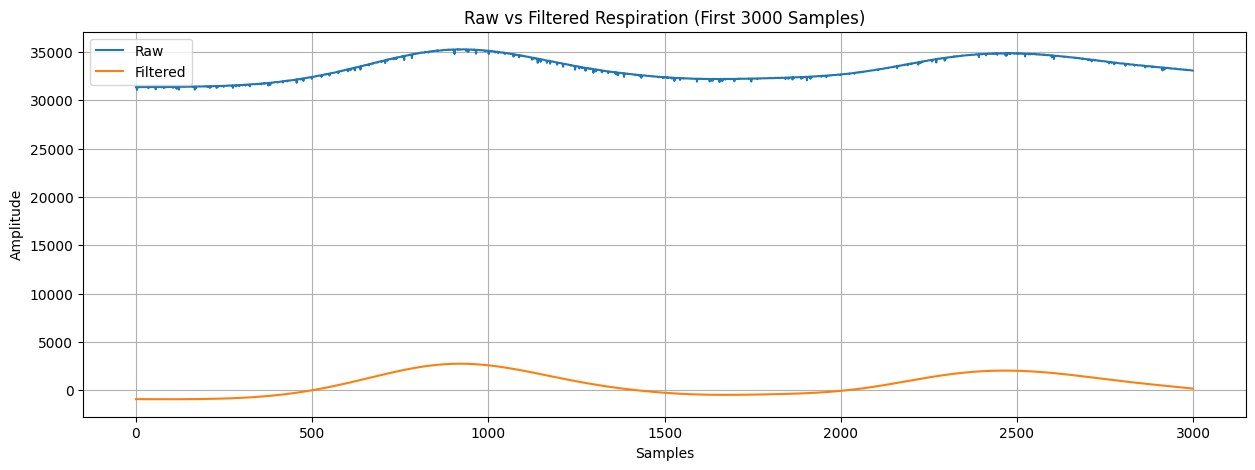

   0  1      2      3      4      5      6      7      8      9
0  0  0  31053  14694  32651  29553  37415  32324  31659  31364
1  1  0  30861  14680  32983  29556  37417  32333  31663  31379
2  2  0  30644  14684  32823  29561  37409  32340  31655  31367
3  3  0  30374  14701  32569  29553  37405  32341  31671  31076
4  4  0  30103  14684  32794  29561  37409  32342  31681  31365


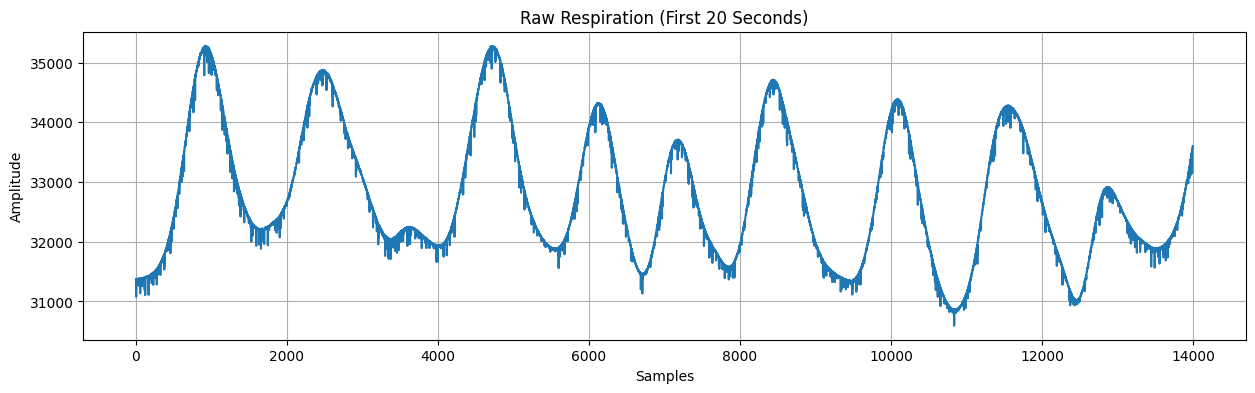

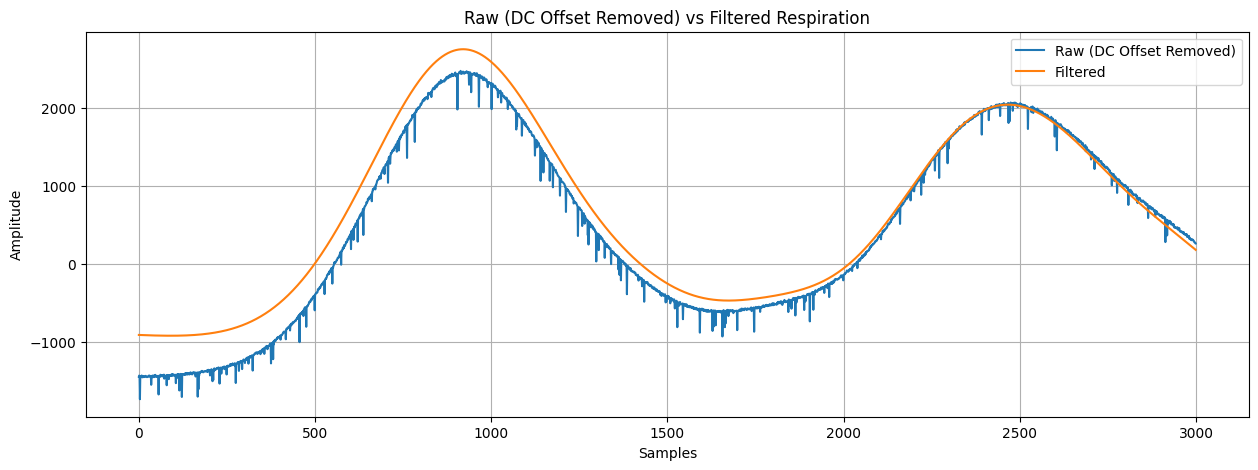

In [75]:
from scipy.signal import butter, sosfiltfilt
RESPIRATION = respiban.iloc[:,9].values

print(RESPIRATION[:10])
fs= 700
lowcut = 0.05
highcut = 2.0
order = 4
nyquist = fs / 2

sos = butter(
    4,
    [lowcut/(fs/2), highcut/(fs/2)],
    btype='band',
    output='sos'
)

RESPIRATION_filtered = sosfiltfilt(sos, RESPIRATION)

 
 

plt.figure(figsize=(15,5))

plt.plot(RESPIRATION,
         label="Raw",
         linewidth=1)

plt.plot(RESPIRATION_filtered,
         label="Filtered",
         linewidth=1)

plt.title("Raw vs Filtered Respiration")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()
samples = 3000

plt.figure(figsize=(15,5))

plt.plot(RESPIRATION[:samples],
         label="Raw",
         linewidth=1.5)

plt.plot(RESPIRATION_filtered[:samples],
         label="Filtered",
         linewidth=1.5)

plt.title("Raw vs Filtered Respiration (First 3000 Samples)")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()
print(respiban.iloc[:5, :10])
seconds = 20
samples = seconds * fs

plt.figure(figsize=(15,4))
plt.plot(RESPIRATION[:samples])
plt.title("Raw Respiration (First 20 Seconds)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()
import matplotlib.pyplot as plt
import numpy as np

# Remove DC offset from raw respiration
RESPIRATION_centered = RESPIRATION - np.mean(RESPIRATION)

# Plot first 3000 samples
samples = 3000

plt.figure(figsize=(15,5))

plt.plot(
    RESPIRATION_centered[:samples],
    label="Raw (DC Offset Removed)",
    linewidth=1.5
)

plt.plot(
    RESPIRATION_filtered[:samples],
    label="Filtered",
    linewidth=1.5
)

plt.title("Raw (DC Offset Removed) vs Filtered Respiration")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

After about 400–500 samples, the filtered signal matches the respiration waveform very well.
The mismatch is only at the beginning, which is a classic edge effect from zero-phase filtering (sosfiltfilt).

For a recording with 4,442,067 samples, the first few hundred samples represent:

4,442,067
500
	​

×100≈0.011%

That's a tiny fraction of the signal.

In [76]:
print(RESPIRATION.dtype)
print(np.isnan(RESPIRATION).sum())
print(np.mean(RESPIRATION_centered))
print(np.mean(RESPIRATION_filtered))

int64
0
1.5789474380798778e-12
0.28856829330893763


In [77]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# ---------------------------------
# Remove DC Offset
# ---------------------------------
RESPIRATION_centered = RESPIRATION - np.mean(RESPIRATION)

# ---------------------------------
# Mean
# ---------------------------------
mean_centered = np.mean(RESPIRATION_centered)
mean_filtered = np.mean(RESPIRATION_filtered)

# ---------------------------------
# Standard Deviation
# ---------------------------------
std_centered = np.std(RESPIRATION_centered)
std_filtered = np.std(RESPIRATION_filtered)

# ---------------------------------
# Noise Estimate
# ---------------------------------
noise_centered = np.std(np.diff(RESPIRATION_centered))
noise_filtered = np.std(np.diff(RESPIRATION_filtered))

# ---------------------------------
# Baseline Drift
# ---------------------------------
window = 7000

drift_centered = np.std(
    np.convolve(
        RESPIRATION_centered,
        np.ones(window)/window,
        mode='same'
    )
)

drift_filtered = np.std(
    np.convolve(
        RESPIRATION_filtered,
        np.ones(window)/window,
        mode='same'
    )
)

# ---------------------------------
# Outlier Count (>3σ)
# ---------------------------------
z_centered = np.abs(
    (RESPIRATION_centered - mean_centered) / std_centered
)

z_filtered = np.abs(
    (RESPIRATION_filtered - mean_filtered) / std_filtered
)

outliers_centered = np.sum(z_centered > 3)
outliers_filtered = np.sum(z_filtered > 3)

# ---------------------------------
# Breath Peak Detection
# ---------------------------------
peaks_centered, _ = find_peaks(
    RESPIRATION_centered,
    distance=fs * 1.5,
    prominence=0.3 * std_centered
)

peaks_filtered, _ = find_peaks(
    RESPIRATION_filtered,
    distance=fs * 1.5,
    prominence=0.3 * std_filtered
)

# ---------------------------------
# Breath Intervals
# ---------------------------------
interval_centered = np.diff(peaks_centered) / fs
interval_filtered = np.diff(peaks_filtered) / fs

# ---------------------------------
# Breathing Rate
# ---------------------------------
duration = len(RESPIRATION) / fs

breathing_rate_centered = len(peaks_centered) / (duration / 60)
breathing_rate_filtered = len(peaks_filtered) / (duration / 60)

# ---------------------------------
# Results Table
# ---------------------------------
results = pd.DataFrame({

    "Metric":[
        "Mean",
        "Std",
        "Noise Estimate",
        "Baseline Drift",
        "Outliers (>3σ)",
        "Breath Count",
        "Mean Breath Interval (s)",
        "Breath Interval Std (s)",
        "Breathing Rate (breaths/min)"
    ],

    "DC Offset Removed":[
        mean_centered,
        std_centered,
        noise_centered,
        drift_centered,
        outliers_centered,
        len(peaks_centered),
        np.mean(interval_centered),
        np.std(interval_centered),
        breathing_rate_centered
    ],

    "Filtered":[
        mean_filtered,
        std_filtered,
        noise_filtered,
        drift_filtered,
        outliers_filtered,
        len(peaks_filtered),
        np.mean(interval_filtered),
        np.std(interval_filtered),
        breathing_rate_filtered
    ]
})

print(results)

                         Metric  DC Offset Removed      Filtered
0                          Mean       1.578947e-12      0.288568
1                           Std       1.897754e+03   1871.786286
2                Noise Estimate       6.688440e+01      5.145265
3                Baseline Drift       3.329169e+02    265.633832
4                Outliers (>3σ)       7.521900e+04  73749.000000
5                  Breath Count       2.172000e+03   2144.000000
6      Mean Breath Interval (s)       2.922143e+00      2.960309
7       Breath Interval Std (s)       8.780914e-01      0.944501
8  Breathing Rate (breaths/min)       2.053639e+01     20.271644


| Metric                       | DC Offset Removed | Filtered | % Change    | Interpretation                                                          |
| ---------------------------- | ----------------- | -------- | ----------- | ----------------------------------------------------------------------- |
| Mean                         | 1.58e-12          | 0.2886   | N/A         | DC removal centers signal, filtering introduces physiological structure |
| Std                          | 1897.75           | 1871.79  | **-1.37%**  | Slight reduction → smoother signal                                      |
| Noise Estimate               | 66.88             | 5.15     | **-92.30%** | 🔥 Major improvement in signal cleanliness                              |
| Baseline Drift               | 332.92            | 265.63   | **-20.22%** | Strong reduction → better stability                                     |
| Outliers (>3σ)               | 75,219            | 73,749   | **-1.95%**  | Slight reduction in extreme artifacts                                   |
| Breath Count                 | 2,172             | 2,144    | **-1.29%**  | Minor reduction → more conservative peak detection                      |
| Mean Breath Interval (s)     | 2.92              | 2.96     | **+1.31%**  | Slight increase → smoother cycle estimation                             |
| Breath Interval Std (s)      | 0.88              | 0.94     | **+7.57%**  | Slight variability increase due to peak refinement                      |
| Breathing Rate (breaths/min) | 20.54             | 20.27    | **-1.29%**  | Stable physiological estimate maintained                                |


Final Conclusion
The filtering stage significantly improves signal quality, especially in:
Noise reduction (~92% decrease, strongest improvement)
Baseline stability (~20% drift reduction)
Signal structure is preserved:
Breathing rate remains stable (~1.3% change)
Breath intervals remain physiologically consistent
Small changes in breath count and variability indicate:
Filtering is removing minor artifacts while preserving true respiration cycles